In [ ]:
import pandas as pd # Импортируем библиотеку pandas для работы с таблицами (DataFrame)
import numpy as np # Импортируем библиотеку numpy для работы с числами, массивами и специальным значением np.nan (пропуски)

df =  pd.read_excel('r33i_os_84_HW2.xlsx', index_col=0) # Читаем Excel-файл, используем первую колонку (с индексами) как индекс датафрейма

df.head() # выводим содержимое датафрейма на экран


,status,popul,cc_marst,cc_occup08,cc_int_y,cc_educ,cc_diplom,cc_age,region,cch3,...,ccj72.171,ccj72.172,ccj72.173,ccj78,ccj161.3y,ccj161.3m,ccj90,ccm1,ccm2,ccm3
idind,,,,,,,,,,,,,,,,,,,,,
92,Село,2800,Состоите в зарегистрированном браке,NaN,2025,10 и более классов школы и какое-либо професс....,законченное среднее образование,66.0,"Ленинградская область, Волосовский район",84,...,Да,3,НЕТ ДЕТЕЙ МОЛОЖЕ 18,Да,41,1.0,Пенсионер и не работаете,80,164,"Среднее, не хорошее, но и не плохое"
108,Село,2800,Bдовец (вдова),NaN,2025,10 и более классов школы и какое-либо професс....,законченное среднее образование,71.5,"Ленинградская область, Волосовский район",88,...,Да,3,НЕТ ДЕТЕЙ МОЛОЖЕ 18,Да,40,0.0,Пенсионер и не работаете,75,154,"Среднее, не хорошее, но и не плохое"
112,Село,2800,Bдовец (вдова),NaN,2025,среднее образование - есть аттестат о ср. обра...,законченное среднее образование,62.5,"Ленинградская область, Волосовский район",89,...,Да,2,НЕТ ДЕТЕЙ МОЛОЖЕ 18,Да,29,0.0,Пенсионер и не работаете,73,162,Плохое
125,Село,2200,Состоите в зарегистрированном браке,работники сферы торговли и услуг,2024,среднее образование - есть аттестат о ср. обра...,законченное среднее образование,61.0,"Ленинградская область, Волосовский район",108,...,Да,3,НЕТ ДЕТЕЙ МОЛОЖЕ 18,NaN,42,0.0,"Работаете на предприятии, в организации, колхо...",100,163,Хорошее
126,Село,2200,Состоите в зарегистрированном браке,работники сферы торговли и услуг,2024,10 и более классов школы и какое-либо професс....,законченное среднее образование,55.5,"Ленинградская область, Волосовский район",108,...,Да,3,НЕТ ДЕТЕЙ МОЛОЖЕ 18,NaN,35,0.0,"Работаете на предприятии, в организации, колхо...",80,169,Хорошее


In [ ]:
missing_values = ["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА"] # Создаём список значений, которые будем считать пропущенными. Например, это ответы: "ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА"

df.replace(missing_values, np.nan, inplace=True) # Заменяем все указанные специальные ответы на np.nan (пропущенные значения) во всём датафрейме df inplace=True означает, что изменения будут внесены сразу в df, без создания новой копии

df = df.infer_objects() # Автоматически определяем более точный тип данных для колонок. Например, если колонка была object (строки) и содержит только числа + NaN, она станет float64. Колонки с текстом останутся object


/tmp/ipython-input-650384122.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(missing_values, np.nan, inplace=True) # Заменяем все указанные специальные ответы на np.nan (пропущенные значения) во всём датафрейме df inplace=True означает, что изменения будут внесены сразу в df, без создания новой копии


In [ ]:
df.info() # Выводим краткую информацию о датафрейме df

<class 'pandas.core.frame.DataFrame'>
Index: 10303 entries, 92 to 65367
Data columns (total 81 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   status      10303 non-null  object 
 1   popul       10303 non-null  int64  
 2   cc_marst    10281 non-null  object 
 3   cc_occup08  5366 non-null   object 
 4   cc_int_y    10303 non-null  int64  
 5   cc_educ     10256 non-null  object 
 6   cc_diplom   10256 non-null  object 
 7   cc_age      10303 non-null  float64
 8   region      10303 non-null  object 
 9   cch3        10303 non-null  int64  
 10  cch4        10303 non-null  int64  
 11  cch5        10303 non-null  object 
 12  cch7.1      10303 non-null  int64  
 13  cch7.2      10303 non-null  object 
 14  cci8        9765 non-null   object 
 15  ccj1        10284 non-null  object 
 16  ccj1.1.1    5343 non-null   object 
 17  ccj1.1.2    5339 non-null   object 
 18  ccj1.1.3    5311 non-null   object 
 19  ccj1.1.4    5156 non-null   o

In [ ]:
from scipy import stats

# Задание 1. Проверка отличия распределения от «нормального»
Выберите три метрические переменные и проанализируйте их распределение. Проведите тест для проверки того отличается ли распределение значений переменных от нормального распределения. Сформулируйте гипотезы и выводы по результатам анализа. Постройте гистограммы распределения с наложенной кривой нормального распределения.


1. ccj72.172 - Сколько всего у Вас детей?

In [ ]:
stats.kstest(df['ccj72.172'].dropna(),'norm', args=(df['ccj72.172'].mean(), df['ccj72.172'].std()))

KstestResult(statistic=np.float64(0.26671197588652074), pvalue=np.float64(0.0), statistic_location=np.float64(2.0), statistic_sign=np.int8(1))

H0 - распределение переменной ccj72.172 не отличается от нормального

H1 - распределение переменной ccj72.172 отличается от нормального

pvalue = 0

уровень значимости = 0.05

pvalue < 0.05, следовательно H0 отвергается

Вывод: принимаем гипотезу H1, распределение переменной ccj72.172 отличается от нормального

---



/tmp/ipython-input-3485336311.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ccj72.172'].dropna(), fit=stats.norm)


<Axes: xlabel='ccj72.172', ylabel='Density'>

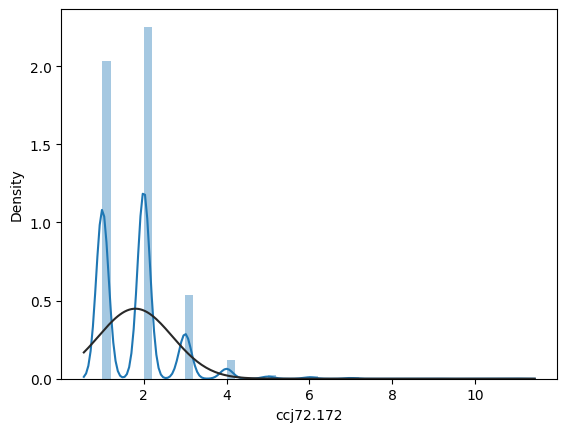

In [ ]:
import seaborn as sns
sns.distplot(df['ccj72.172'].dropna(), fit=stats.norm)

Данный график еще раз подтверждает факт НЕ нормального распределения

2. cc_age - Возраст респондента

In [ ]:
stats.kstest(df['cc_age'].dropna(),'norm', args=(df['cc_age'].mean(), df['cc_age'].std()))

KstestResult(statistic=np.float64(0.050875147361708506), pvalue=np.float64(1.2904391076397242e-23), statistic_location=np.float64(62.5), statistic_sign=np.int8(-1))

H0 - распределение переменной cc_age не отличается от нормального

H1 - распределение переменной cc_age отличается от нормального

pvalue = 1.2904391076397242e-23 - очень маленькое значение

уровень значимости = 0.05

pvalue < 0.05, следовательно H0 отвергается

Вывод: принимаем гипотезу H1, распределение переменной возраста отличается от нормального


/tmp/ipython-input-103349777.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cc_age'].dropna(), fit=stats.norm)


<Axes: xlabel='cc_age', ylabel='Density'>

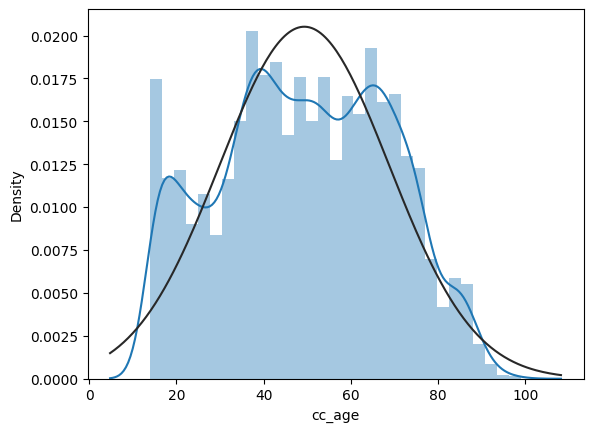

In [ ]:
sns.distplot(df['cc_age'].dropna(), fit=stats.norm)

Данный график еще раз подтверждает факт НЕ нормального распределения

3. ccj10 - Сколько денег в течение последних 30 дней Вы получили по основному месту работы после вычета налогов и отчислений? Если все или часть денег Вы получили в иностранной валюте, переведите все в рубли и назовите общую сумму

In [ ]:
stats.kstest(df['ccj10'].dropna(),'norm', args=(df['ccj10'].mean(), df['ccj10'].std()))

KstestResult(statistic=np.float64(0.16499697188614637), pvalue=np.float64(2.7812380372679947e-121), statistic_location=np.float64(50000.0), statistic_sign=np.int8(1))

H0 - распределение переменной ccj10 не отличается от нормального

H1 - распределение переменной ccj10 отличается от нормального

pvalue = 2.7812380372679947e-121 - очень маленькое значение

уровень значимости = 0.05

pvalue < 0.05, следовательно H0 отвергается

Вывод: принимаем гипотезу H1, распределение переменной ccj10 отличается от нормального

/tmp/ipython-input-1963682616.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ccj10'].dropna(), fit=stats.norm)


<Axes: xlabel='ccj10', ylabel='Density'>

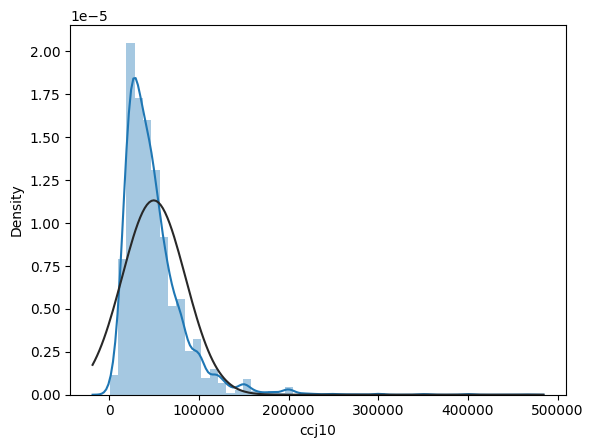

In [ ]:
sns.distplot(df['ccj10'].dropna(), fit=stats.norm)

Данный график еще раз подтверждает факт НЕ нормального распределения

# Задание 2. Тест Хи-квадрат
Выберите подходящие переменные и проведите тест Хи-квадрат (рассмотрите не менее трёх разных пар переменных). Можно использовать как исходные переменные, так и перекодировать их. Постройте для выбранных пар переменных таблицы сопряженности и прокомментируйте их. Сформулируйте гипотезы. Проинтерпретируйте результаты анализа. Обоснуйте свои выводы.


1. Гипотеза связи между удовлетворенность работой и доходом

H0 - Удовлетворенность работой не зависит от уровня дохода за последние 30 дней.

H1 - Удовлетворенность работой зависит от уровня дохода за последние 30 дней.

ccj1.1.1 - Насколько Вы удовлетворены или не удовлетворены Вашей работой в целом?

ccj10 - Сколько денег в течение последних 30 дней Вы получили по основному месту работы после вычета налогов и отчислений? Если все или часть денег Вы получили в иностранной валюте, переведите все в рубли и назовите общую сумму

In [ ]:
df['ccj10'].describe()

,ccj10
count,5078.000000
mean,49614.761071
std,35240.430539
min,600.000000
25%,27000.000000
50%,40000.000000
75%,60000.000000
max,465000.000000


In [ ]:
bins = [0, 27000, 40000, 60000, 465000]  # границы категорий
labels = ['Очень низкая', 'Низкая', 'Средняя', 'Высокая']  # подписи для категорий

df['salary_category'] = pd.cut(df['ccj10'], bins=bins, labels=labels, include_lowest=True)
df['salary_category']

,salary_category
idind,
92,NaN
108,NaN
112,NaN
125,Очень низкая
126,Средняя
...,...
65363,NaN
65364,NaN
65365,NaN


In [ ]:
ct_salary_cat = pd.crosstab(df['ccj1.1.1'], df['salary_category'])
ct_salary_cat

salary_category,Очень низкая,Низкая,Средняя,Высокая
ccj1.1.1,,,,
"И ДА, И НЕТ",227,216,217,134
ПОЛНОСТЬЮ УДОВЛЕТВОРЕНЫ,211,231,293,363
СКОРЕЕ НЕ УДОВЛЕТВОРЕНЫ,70,55,33,22
СКОРЕЕ УДОВЛЕТВОРЕНЫ,761,819,725,648
СОВСЕМ НЕ УДОВЛЕТВОРЕНЫ,6,7,4,2


Комментарии:

Анализ таблицы показывает, что существует прямая положительная связь между категорией зарплаты и уровнем удовлетворенности. Наиболее наглядно это демонстрирует группа «Полностью удовлетворены», численность которой стабильно растет от более низких к высоким зарплатам. В то же время, доли сотрудников в категориях «Скорее не удовлетворены» и «Совсем не удовлетворены» закономерно снижаются. Эти данные наглядно иллюстрируют, что уровень дохода за последние 30 дней может оказывать влияние на удовлетворенность работой, и служат основанием для проведения статистического теста χ² для проверки значимости этой зависимости.

In [ ]:
stats.chi2_contingency(ct_salary_cat)

Chi2ContingencyResult(statistic=np.float64(128.13663590613874), pvalue=np.float64(1.459509106797208e-21), dof=12, expected_freq=array([[200.7038065 , 209.04678826, 200.23156225, 184.01784298],
       [277.54758128, 289.08485329, 276.89452815, 254.47303727],
       [ 45.49960349,  47.39095956,  45.3925456 ,  41.71689136],
       [746.4462728 , 777.47501983, 744.68992863, 684.38877875],
       [  4.80273592,   5.00237906,   4.79143537,   4.40344964]]))

Итоги:



*   Уровень значимости = 0.05
*   pvalue = 1.459509106797208e-21, pvalue < 0.05

Вывод: H0 - отвергается, принимается гипотеза H1. Распределение удовлетворенности отличается между разными категориями зарплаты.



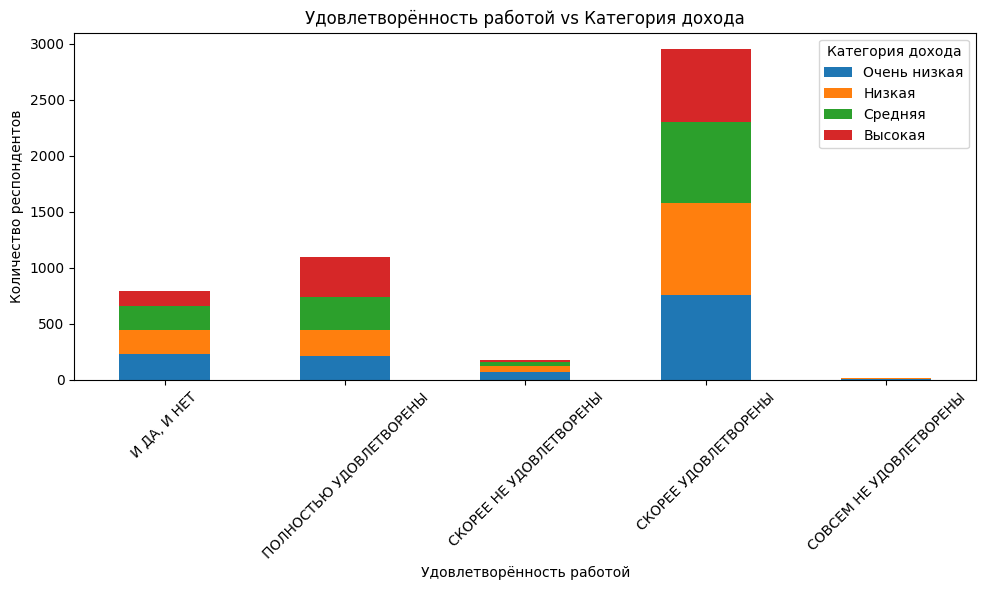

In [ ]:
import matplotlib.pyplot as plt
ct = ct_salary_cat.copy()

ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Удовлетворённость работой vs Категория дохода")
plt.xlabel("Удовлетворённость работой")
plt.ylabel("Количество респондентов")
plt.xticks(rotation=45)
plt.legend(title="Категория дохода")
plt.tight_layout()
plt.show()


Построена столбчатая диаграмма с накоплением, показывающая распределение категорий дохода внутри уровней удовлетворённости работой. График демонстрирует, что по мере роста удовлетворённости увеличивается доля респондентов с высокой и средней категорией дохода, тогда как среди менее удовлетворённых преобладают низкие и очень низкие доходы. Это визуально подтверждает наличие статистически значимой зависимости между уровнем дохода и удовлетворённостью работой.

2. Гипотеза связи между уровнем образования и пренадлежностью к профессиональной группе

H0 - Принадлежность к какой-либо профессиональной группе не зависит от его уровня образования.

H1 - Принадлежность к какой-либо профессиональной группе зависит от его уровня образования.

cc_occup08 - ПРОФЕССИОНАЛЬНАЯ ГРУППА

cc_diplom - ЗАКОНЧЕННОЕ ОБРАЗОВАНИЕ (ГРУППА)

In [ ]:
ct_educ_prof = pd.crosstab(df['cc_occup08'], df['cc_diplom'])
ct_educ_prof

cc_diplom,законченное высшее образование и выше,законченное среднее образование,законченное среднее специальное образование,незаконченное среднее образование (7 - 8 кл),незаконченное среднее образование (7 - 8 кл) + что-то еще,окончил 0 - 6 классов
cc_occup08,,,,,,
военнослужащие,17,4,9,0,4,0
законодатели; крупные чиновники; руководители высш. и сред. звена,201,30,53,0,13,0
"квалифицированные работники сельского, лесного хоз-ва и рыбоводства",4,4,1,0,0,0
"квалифицированные рабочие, занятые ручным трудом",78,285,197,18,73,0
"квалифицированные рабочие, использующие машины и механизмы",69,316,161,16,66,2
неквалифицированные рабочие всех отраслей,27,183,88,22,80,5
работники сферы торговли и услуг,176,404,303,17,90,0
служащие офисные и по обслуживанию клиентов,97,74,111,1,18,0
специалисты высшего уровня квалификации,758,36,170,1,4,0


Анализ таблицы сопряжённости показывает выраженную зависимость между уровнем образования и профессиональной группой респондентов. Можно заметить, что высшее и среднее профессиональное образование значительно чаще встречается среди «специалистов высшего уровня квалификации», «специалистов среднего уровня» и работников офисной сферы. Например, среди специалистов высшего уровня квалификации преобладают респонденты с законченным высшим образованием (758 человек), что логично отражает требования к таким должностям.

В то же время респонденты с средним или средним специальным образованием чаще представлены среди квалифицированных рабочих ручного труда, операторов машин и механизмов, а также работников сферы торговли и услуг. Например, среди квалифицированных рабочих, выполняющих ручной труд, 285 имеют среднее, а 197 — среднее специальное образование.

Группы с незаконченным средним образованием и особенно с образованием на уровне 0–6 классов заметно более представлены среди неквалифицированных рабочих, в то время как в высококвалифицированных профессиях такие уровни образования практически не встречаются.

В совокупности данные демонстрируют ожидаемую социально-экономическую закономерность: чем выше уровень образования, тем выше вероятность того, что человек занимает квалифицированную или управленческую должность, тогда как более низкий уровень образования чаще связан с рабочими или неквалифицированными профессиями.

In [ ]:
stats.chi2_contingency(ct_educ_prof)

Chi2ContingencyResult(statistic=np.float64(2064.916766732881), pvalue=np.float64(0.0), dof=45, expected_freq=array([[1.19670843e+01, 9.51262390e+00, 9.63343931e+00, 5.02337759e-01,
        2.34000374e+00, 4.45109407e-02],
       [1.04536001e+02, 8.30955676e+01, 8.41509258e+01, 4.38806808e+00,
        2.04406209e+01, 3.88816159e-01],
       [3.16775762e+00, 2.51804750e+00, 2.55002805e+00, 1.32971760e-01,
        6.19412755e-01, 1.17823078e-02],
       [2.29134468e+02, 1.82138769e+02, 1.84452029e+02, 9.61829063e+00,
        4.48041893e+01, 8.52253600e-01],
       [2.21743033e+02, 1.76263325e+02, 1.78501964e+02, 9.30802319e+00,
        4.33588928e+01, 8.24761549e-01],
       [1.42549093e+02, 1.13312138e+02, 1.14751262e+02, 5.98372919e+00,
        2.78735740e+01, 5.30203853e-01],
       [3.48453338e+02, 2.76985225e+02, 2.80503086e+02, 1.46268936e+01,
        6.81354030e+01, 1.29605386e+00],
       [1.05943894e+02, 8.42146998e+01, 8.52842716e+01, 4.44716664e+00,
        2.07159155e+01, 3.94

Итоги:



*   Уровень значимости = 0.05
*   pvalue = 0, pvalue < 0.05

Вывод: H0 - отвергается, принимается гипотеза H1 о наличии связи между профессиональной группой и уровнем образования.

3. Гипотеза о связи уровня образования и количеством детей.

H0 - Уровень образования респондента не связан с количеством детей.

H1 - Уровень образования респондента связан с количеством детей.

cc_diplom - ЗАКОНЧЕННОЕ ОБРАЗОВАНИЕ (ГРУППА)

ccj72.172 - Сколько всего у Вас детей?

In [ ]:
ct_dip_life = pd.crosstab(df['cc_diplom'], df['ccj72.172'])
ct_dip_life

ccj72.172,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
cc_diplom,,,,,,,,,,,
законченное высшее образование и выше,987,1007,188,32,10,3,0,0,0,0,2
законченное среднее образование,882,1049,286,61,14,12,6,1,0,2,1
законченное среднее специальное образование,872,912,188,38,0,4,2,1,0,0,0
незаконченное среднее образование (7 - 8 кл),86,138,51,14,8,2,2,0,1,0,0
незаконченное среднее образование (7 - 8 кл) + что-то еще,176,209,67,30,6,5,2,0,1,0,0
окончил 0 - 6 классов,9,21,10,2,0,0,1,0,1,0,0


Таблица сопряженности показывает, что респонденты с высшим образованием чаще имеют одного или двух детей: 987 человек имеют одного ребёнка, 1007 — двух. Трое и более детей встречаются значительно реже, и почти отсутствуют семьи с очень большим количеством детей.

Для людей с средним и средним специальным образованием также преобладают семьи с одним или двумя детьми, но доля семей с тремя и более детьми выше, чем среди обладателей высшего образования. Например, среди закончивших среднее образование 286 человек имеют троих детей, а среди средне-специального — 188.

Респонденты с незаконченным средним образованием или меньшим чаще имеют большие семьи: в этих группах встречаются семьи с четырьмя и более детьми относительно чаще, чем среди высокообразованных респондентов.

В целом таблица демонстрирует зависимость между уровнем образования и количеством детей: чем выше образование, тем чаще семьи небольшие, а более низкий уровень образования ассоциирован с большим количеством детей.

In [ ]:
stats.chi2_contingency(ct_dip_life)

Chi2ContingencyResult(statistic=np.float64(273.3989826722766), pvalue=np.float64(1.5167263566577695e-32), dof=50, expected_freq=array([[9.07018103e+02, 1.00458579e+03, 2.37896514e+02, 5.33008646e+01,
        1.14431235e+01, 7.82950554e+00, 3.91475277e+00, 6.02269657e-01,
        9.03404485e-01, 6.02269657e-01, 9.03404485e-01],
       [9.41606052e+02, 1.04289435e+03, 2.46968387e+02, 5.53334234e+01,
        1.18794920e+01, 8.12807349e+00, 4.06403675e+00, 6.25236423e-01,
        9.37854634e-01, 6.25236423e-01, 9.37854634e-01],
       [8.20751689e+02, 9.09039719e+02, 2.15270197e+02, 4.82314239e+01,
        1.03547690e+01, 7.08484193e+00, 3.54242097e+00, 5.44987841e-01,
        8.17481762e-01, 5.44987841e-01, 8.17481762e-01],
       [1.22888949e+02, 1.36108079e+02, 3.22318292e+01, 7.22156174e+00,
        1.55039179e+00, 1.06079438e+00, 5.30397190e-01, 8.15995677e-02,
        1.22399352e-01, 8.15995677e-02, 1.22399352e-01],
       [2.01830857e+02, 2.23541745e+02, 5.29370440e+01, 1.18605782e+

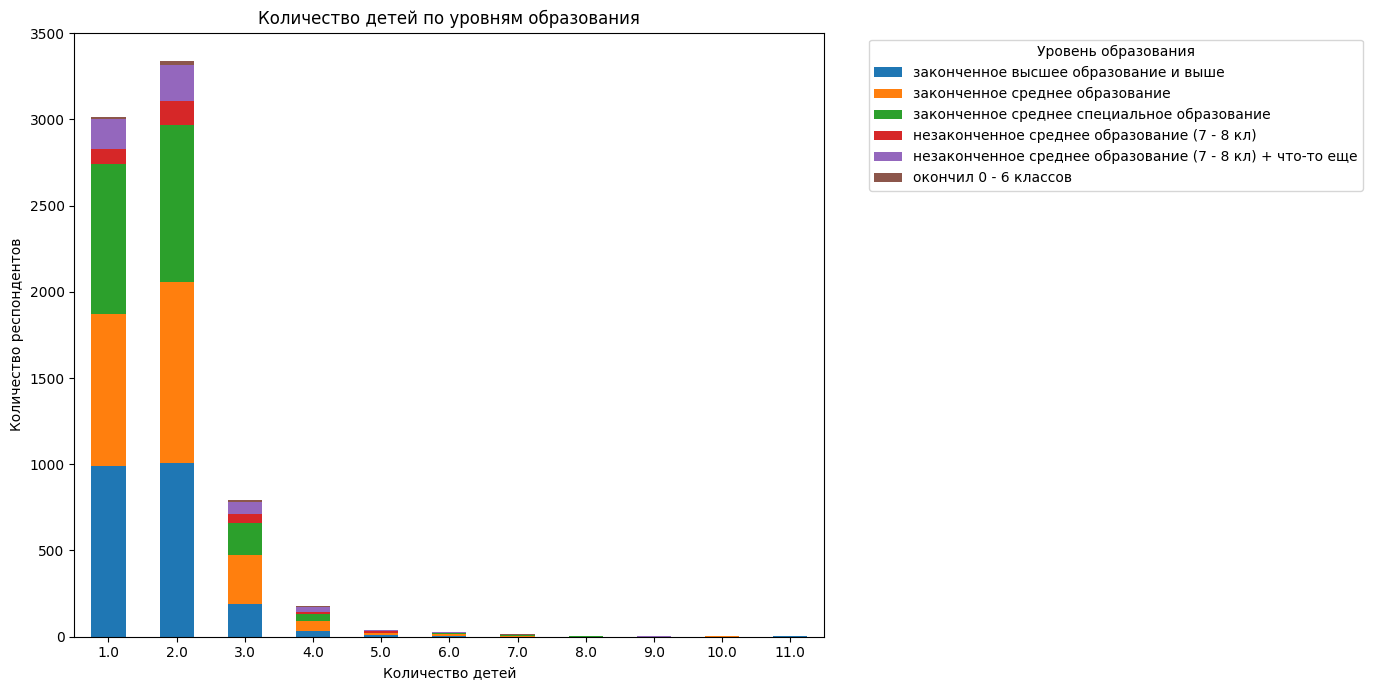

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
e = pd.crosstab(df['cc_diplom'], df['ccj72.172'])
e.T.plot(kind='bar', stacked=True, figsize=(14,7))

plt.title('Количество детей по уровням образования')
plt.xlabel('Количество детей')
plt.ylabel('Количество респондентов')
plt.xticks(rotation=0)
plt.legend(title='Уровень образования', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Итоги:


*   pvalue = 1.5167263566577695e-32
*   Уровень значимости = 0.05, pvalue < 0.05

Вывод: H0 - отвергается, принимается гипотеза H1.

4. Гипотеза о связи между полом и уровнем дохода за последние 30 дней.

H0 - Пол не связан с уровнем дохода за последние 30 дней.

H1 - Пол связан с уровнем дохода за последние 30 дней.

cch5 - Пол респондента

salary_category - Категория дохода за последние 30 дней

In [ ]:
ct_sex_salary = pd.crosstab(df['cch5'], df['salary_category'])
ct_sex_salary

salary_category,Очень низкая,Низкая,Средняя,Высокая
cch5,,,,
ЖЕНСКИЙ,905,801,592,372
МУЖСКОЙ,387,531,683,807


Можно заметить явную тенденцию: среди женщин преобладают категории с низкой и очень низкой зарплатой — 905 женщин имеют очень низкую и 801 — низкую зарплату. При этом число женщин с высокой зарплатой значительно меньше (372 человека).

У мужчин наблюдается обратная тенденция: в категориях средней и высокой зарплаты их больше — 683 человека имеют среднюю, а 807 — высокую зарплату. В то же время число мужчин с очень низкой зарплатой сравнительно невелико (387).

В целом данные демонстрируют гендерное различие в доходах: мужчины чаще находятся в более высоких зарплатных категориях, а женщины — в более низких.

In [ ]:
stats.chi2_contingency(ct_sex_salary)

Chi2ContingencyResult(statistic=np.float64(416.99407058014265), pvalue=np.float64(4.612441269089186e-90), dof=3, expected_freq=array([[679.33044506, 700.36234738, 670.39188657, 619.91532099],
       [612.66955494, 631.63765262, 604.60811343, 559.08467901]]))

Итоги:


*   pvalue = 4.612441269089186e-90
*   Уровень значимости = 0.05, pvalue < 0.05

Вывод: H0 - отвергается, принимается гипотеза H1.

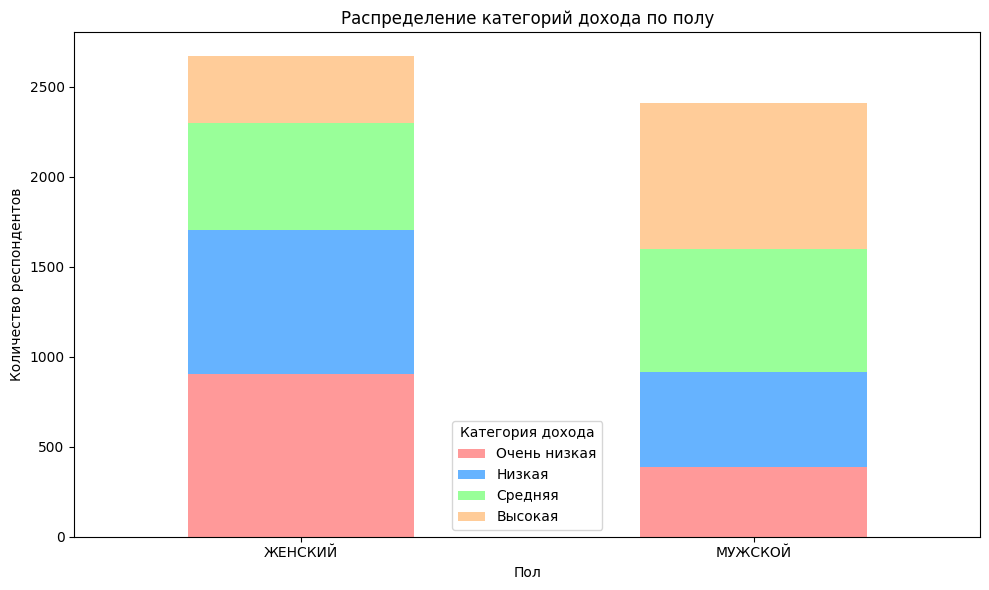

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ct_sex_salary = pd.crosstab(df['cch5'], df['salary_category'])

ct_sex_salary.plot(kind='bar', stacked=True, figsize=(10,6), color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title('Распределение категорий дохода по полу')
plt.xlabel('Пол')
plt.ylabel('Количество респондентов')
plt.legend(title='Категория дохода')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


5. Гипотеза о связи между женским здоровьем и количеством детей.

H0 - Женское здоровье не связано с количеством детей.

H1 - Женское здоровье связано с количеством детей.

ccj72.172 - Кол-во детей

ccm3 - Уровень здоровья

In [ ]:
women = df[df['cch5'] == 'ЖЕНСКИЙ']

In [ ]:
ct_women_health = pd.crosstab(women['ccm3'], women['ccj72.172'])
ct_women_health

ccj72.172,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
ccm3,,,,,,,,,,,
Очень хорошее,11,17,6,1,0,1,1,0,0,0,0
Плохое,283,287,59,8,4,3,1,0,1,0,0
Совсем плохое,21,23,10,3,0,0,0,0,0,0,0
"Среднее, не хорошее, но и не плохое",1103,1267,271,34,14,11,4,1,1,0,1
Хорошее,522,481,141,45,10,3,3,0,0,1,0


Наиболее заметно, что женщины с меньшим количеством детей (1–2) преобладают во всех категориях здоровья. Например, в категории «Среднее, не хорошее, но и не плохое» 1103 женщины имеют одного ребёнка, а 1267 — двух, что является самой многочисленной группой.

Женщины с очень хорошим и хорошим здоровьем встречаются реже, и их число снижается с ростом числа детей. Например, «очень хорошее» здоровье наблюдается лишь у единичных женщин с 4–7 детьми.

Состояние плохое и совсем плохое также встречается преимущественно среди женщин с 1–3 детьми, при этом абсолютные значения снижаются с ростом числа детей, вероятно из-за уменьшения численности женщин с большим количеством детей.

В целом таблица демонстрирует тенденцию к тому, что женщины с большим числом детей реже встречаются во всех категориях здоровья, а распределение состояния здоровья наиболее сконцентрировано среди женщин с 1–2 детьми. Это позволяет предположить возможную связь между количеством детей и состоянием здоровья женщин, которую можно проверить с помощью χ²-теста.

In [ ]:
stats.chi2_contingency(ct_women_health)

Chi2ContingencyResult(statistic=np.float64(78.72873281131969), pvalue=np.float64(0.0002486748476071232), dof=40, expected_freq=array([[1.54266065e+01, 1.65001075e+01, 3.87255534e+00, 7.23619170e-01,
        2.22652052e-01, 1.43133462e-01, 7.15667311e-02, 7.95185902e-03,
        1.59037180e-02, 7.95185902e-03, 7.95185902e-03],
       [2.69340211e+02, 2.88082957e+02, 6.76127230e+01, 1.26339996e+01,
        3.88738448e+00, 2.49903288e+00, 1.24951644e+00, 1.38835160e-01,
        2.77670320e-01, 1.38835160e-01, 1.38835160e-01],
       [2.37653127e+01, 2.54190845e+01, 5.96582850e+00, 1.11476467e+00,
        3.43004513e-01, 2.20502901e-01, 1.10251451e-01, 1.22501612e-02,
        2.45003224e-02, 1.22501612e-02, 1.22501612e-02],
       [1.12864389e+03, 1.20718354e+03, 2.83324522e+02, 5.29415431e+01,
        1.62897056e+01, 1.04719536e+01, 5.23597679e+00, 5.81775199e-01,
        1.16355040e+00, 5.81775199e-01, 5.81775199e-01],
       [5.02823985e+02, 5.37814313e+02, 1.26224371e+02, 2.35860735e+0

Итоги:


*   pvalue = 0.0002486748476071232
*   Уровень значимости = 0.05, pvalue < 0.05

Вывод: H0 - отвергается, принимается гипотеза H1.

# Задание 3. Парная корреляция
Проведите корреляционный анализ переменных (рассмотрите не менее трёх разных пар переменных). Обоснуйте выбор рассчитываемых коэффициентов корреляции. Сформулируйте гипотезы. Проинтерпретируйте результаты анализа (статистическая значимость, сила и направление взаимосвязи). Заполните таблицу (не менее 3 записей).


1. Гипотеза о связи кол-ва сотрудников и кол-ва недоплаченных средств

H0 - Не существует статистически значимой линейной связи между размером предприятия (количеством работников) и общей суммой недоплаченных денег.

H1 - Существует положительная корреляция между размером предприятия (количеством работников) и общей суммой недоплаченных денег. Чем больше предприятие, тем больше сумма недоплат.

ccj13 - Сколько человек работает на Вашем предприятии? Если не знаете точно, скажите примерно

ccj15 - Сколько всего денег Вам не доплатили?

Используется коэф. корреляции Пирсона, так как это две числовые переменные.

In [ ]:
clean_df = df[['ccj13', 'ccj15']].dropna()

In [ ]:
clean_df['ccj13'].corr(clean_df['ccj15']) #коэффициент корреляции Пирсона между парой переменных

np.float64(0.351562704675)

In [ ]:
stats.pearsonr(clean_df.ccj13, clean_df.ccj15)

PearsonRResult(statistic=np.float64(0.3515627046750001), pvalue=np.float64(0.1086207873134573))

Выводы:

Коэффициент корреляции Пирсона (r) = 0.352

Это положительная корреляция, то есть направление связи соответствует H1.
Положительное значение (r > 0) означает: чем больше предприятие, тем выше может быть сумма недоплат.

Но по силе это: от 0.3 до 0.5 – умеренная

Значит, связь умеренная, но недостаточно сильная и нестабильная, чтобы считаться статистически значимой в данной выборке.

p-value = 0.1086

Уровень значимости = 0.05, p-value > 0.05

H0 не отвергается. Мы не можем утверждать, что существует статистически значимая линейная связь между количеством работников на предприятии и суммой недоплат.


<Axes: xlabel='ccj13', ylabel='ccj15'>

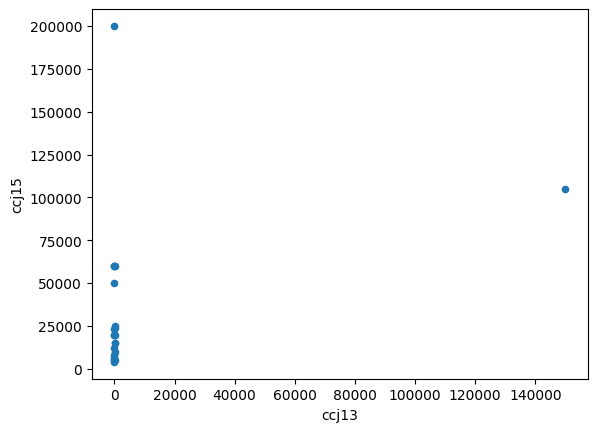

In [ ]:
df.plot('ccj13', 'ccj15', kind='scatter') #диаграмма рассеяния

Итог: Хотя между размером предприятия и суммой недоплат наблюдается умеренная положительная связь, полученные данные не позволяют считать эту связь статистически значимой

2. Гипотеза о связи уровня образования и удовлетворенностью условиями труда

H0 - Не существует статистически значимой линейной связи между уровнем образования и удовлетворенностью условиями труда.

H1 - Существует статистически значимой линейной связи между уровнем образования и удовлетворенностью условиями труда.

cc_diplom - Законченное образование

ccj1.1.2 - Насколько Вы удовлетворены или не удовлетворены условиями Вашего труда?

Используется коэф. корреляции Спирмена, потому что обе переменные являются категориальными порядковыми — они имеют категории, расположенные в определённом порядке, поэтому в данном случае корректно оценивается связь между такими упорядоченными данными.

In [ ]:
edu_map = {
    "окончил 0 - 6 классов": 1,
    "незаконченное среднее образование (7 - 8 кл)": 2,
    "незаконченное среднее образование (7 - 8 кл) + что-то еще": 3,
    "законченное среднее специальное образование": 4,
    "законченное среднее образование": 5,
    "законченное высшее образование и выше": 6
}


In [ ]:
sat_map = {
    "СОВСЕМ НЕ УДОВЛЕТВОРЕНЫ": 1,
    "СКОРЕЕ НЕ УДОВЛЕТВОРЕНЫ": 2,
    "И ДА, И НЕТ": 3,
    "СКОРЕЕ УДОВЛЕТВОРЕНЫ": 4,
    "ПОЛНОСТЬЮ УДОВЛЕТВОРЕНЫ": 5
}

In [ ]:

df["edu_code"] = df["cc_diplom"].map(edu_map)
df["sat_code"] = df["ccj1.1.2"].map(sat_map)

In [ ]:
c_df = df[['edu_code', 'sat_code']].dropna()
c_df

,edu_code,sat_code
idind,,
125,5.0,3.0
126,5.0,4.0
127,3.0,2.0
260,6.0,4.0
316,4.0,3.0
...,...,...
65357,4.0,5.0
65359,3.0,4.0
65360,4.0,4.0


In [ ]:
from scipy.stats import spearmanr
spearmanr(c_df.edu_code, c_df.sat_code)

SignificanceResult(statistic=np.float64(0.10634348487763776), pvalue=np.float64(7.440937552092573e-15))

Выводы:

Коэффициент корреляции Спирмена (ρ) = 0.106

ρ > 0 - положительная связь: с ростом уровня образования удовлетворённость условиями труда слегка повышается.
Однако связь очень слабая, практически несущественная по силе.

p-value = 7.440937552092573e-15

Уровень значимости = 0.05, p-value < 0.05

H0 отвергается. Существует статистически значимая, но очень слабая положительная связь между уровнем образования и удовлетворённостью условиями труда: более высокий уровень образования немного связан с большей удовлетворённостью, но эффект почти незаметен на практике.


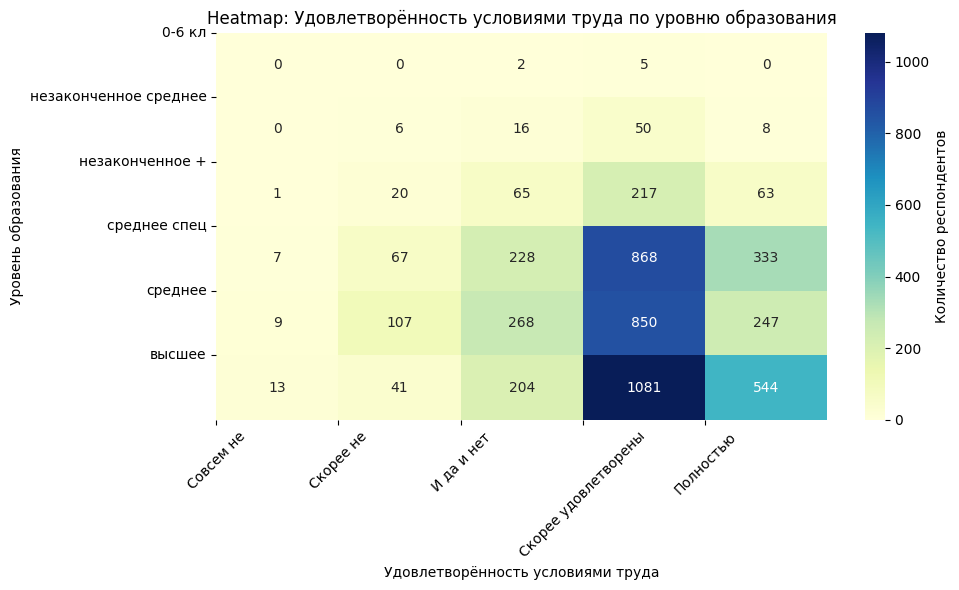

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Создаём кросстаб (таблицу сопряжённости)
heat_data = pd.crosstab(df['edu_code'], df['sat_code'])

# Строим heatmap
plt.figure(figsize=(10,6))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Количество респондентов'})

# Подписываем оси
plt.xticks(ticks=[0,1,2,3,4], labels=["Совсем не","Скорее не","И да и нет","Скорее удовлетворены","Полностью"], rotation=45)
plt.yticks(ticks=[0,1,2,3,4,5], labels=["0-6 кл","незаконченное среднее","незаконченное +","среднее спец","среднее","высшее"], rotation=0)
plt.xlabel('Удовлетворённость условиями труда')
plt.ylabel('Уровень образования')
plt.title('Heatmap: Удовлетворённость условиями труда по уровню образования')
plt.tight_layout()
plt.show()



3. Гипотеза о связи между полом и наличием подчиненных

H0 - Пол не связан с наличием подчиненных.

H1 - Пол не связан с наличием подчиненных.

cch5 - Пол респондента

ccj6 - У Вас есть подчиненные на этой работе?

*Phi-коэффициент (Phi Coefficient) — статистический показатель, который оценивает степень связи между двумя бинарными переменными. Это специальный случай коэффициента корреляции Пирсона, используется, когда обе переменные могут принимать только два возможных значения*

Используется Фи коэф., потому что обе переменные (пол и наличие подчинённых) бинарные и номинальные, а φи корректно оценивает силу и направление такой связи.

Кроме того, будем использовать Хи-квадрат, который поможет проверить зависимость переменных и оценить силу связи.

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
df['sex_code'] = df['cch5'].map({'ЖЕНСКИЙ': 0, 'МУЖСКОЙ': 1})
df['sub_code'] = df['ccj6'].map({'Нет': 0, 'Да': 1})

In [ ]:
ct_sex_sub = pd.crosstab(df['sex_code'], df['sub_code'])
ct_sex_sub

sub_code,0.0,1.0
sex_code,,
0,2391,453
1,2097,435


Из таблицы видно, что большинство респондентов не имеют подчинённых. Среди женщин 453 человека имеют подчинённых, среди мужчин — 435. Процент работников с подчинёнными немного выше у женщин (453/2844 ≈ 15.9%) по сравнению с мужчинами (435/2532 ≈ 17.2%), но разница небольшая.

In [ ]:
phi = np.sqrt(chi2_contingency(ct_sex_sub)[0] / df.shape[0])
phi

np.float64(0.011792552989383646)

In [ ]:
stats.chi2_contingency(ct_sex_sub)

Chi2ContingencyResult(statistic=np.float64(1.43277954479446), pvalue=np.float64(0.23131135045888243), dof=1, expected_freq=array([[2374.23214286,  469.76785714],
       [2113.76785714,  418.23214286]]))

Выводы:

χ² = 1.433

p-value = 0.2313

p-value > 0.05 - нет статистических оснований отклонять нулевую гипотезу H0.

Это значит, что пол респондента не связан с наличием подчинённых на статистически значимом уровне.

φи = 0.0118 — это очень слабая положительная связь между полом и наличием подчинённых. Положительное значение φи указывает, что мужчины немного чаще имеют подчинённых, чем женщины, но эффект практически незаметен.

Итог: Анализ показывает, что между полом респондента и наличием подчинённых нет заметной зависимости. Коэффициент Фи очень низкий (0.012), а χ² тест не дал статистически значимого результата (p = 0.231). На практике это означает, что наличие подчинённых не зависит от пола сотрудника, и обе группы (мужчины и женщины) имеют примерно одинаковую вероятность быть руководителями.

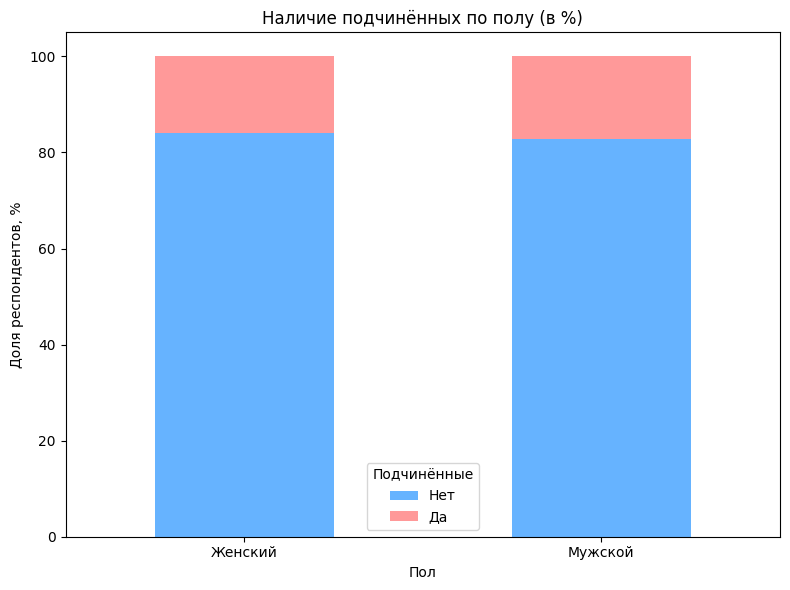

In [ ]:
ct_sex_sub_pct = ct_sex_sub.div(ct_sex_sub.sum(axis=1), axis=0) * 100

ct_sex_sub_pct.plot(kind='bar', stacked=True, figsize=(8,6), color=['#66b3ff','#ff9999'])

plt.title('Наличие подчинённых по полу (в %)')
plt.xlabel('Пол')
plt.ylabel('Доля респондентов, %')
plt.xticks([0,1], ['Женский','Мужской'], rotation=0)
plt.legend(title='Подчинённые', labels=['Нет','Да'])
plt.tight_layout()
plt.show()


# Таблица

| Анализируемые пары переменных | Выбранный коэффициент корреляции (обоснование выбора) | Гипотеза | Сила взаимосвязи | Направление взаимосвязи | Статистическая значимость взаимосвязи |
|-------------------------------|--------------------------------------------------------|----------|-------------------|---------------------------|----------------------------------------|
| **1. Кол-во сотрудников (ccj13) и сумма недоплат (ccj15)** | Коэффициент Пирсона — обе переменные числовые. | **H0:** нет линейной связи. **H1:** положительная связь: больше сотрудников → больше недоплат. | Умеренная (r = 0.352). | Положительная (r > 0). | p = 0.1086 > 0.05 → **H0 не отвергается**. Связь статистически незначима. |
| **2. Уровень образования (cc_diplom) и удовлетворённость условиями труда (ccj1.1.2)** | Коэффициент Спирмена — обе переменные порядковые. | **H0:** связи нет. **H1:** есть связь между образованием и удовлетворённостью. | Очень слабая (ρ = 0.106). | Положительная (ρ > 0). | p < 0.05 → **H0 отвергается**. Связь статистически значима, но почти нулевая по силе. |
| **3. Пол (cch5) и наличие подчинённых (ccj6)** | Коэффициент Фи и χ² — обе переменные бинарные. | **H0:** пол не связан с подчинёнными. **H1:** есть связь. | Очень слабая (φ = 0.0118). | Положительная, но практически отсутствующая. | p = 0.2313 > 0.05 → **H0 не отвергается**. Связь статистически незначима. |


# Задание 4.  
Какие другие показатели (возможно, что их нет в представленных данных) могли повлиять на характер взаимосвязи между выбранными в п. 2 и п. 3 переменными? Почему изучения взаимосвязи только между двумя выбранными переменными часто недостаточно?

1. Уровень образования ↔ Удовлетворённость условиями труда

На связь могли влиять дополнительные переменные, которые не включены в твой анализ:

Должность — руководители и специалисты часто более удовлетворены, независимо от образования.

Стаж работы — более опытные сотрудники обычно стабильнее относятся к условиям.

Отрасль, характер работы — комфорт труда сильно зависит от сектора, а не образования.

Заработная плата — ключевой фактор удовлетворённости; образование влияет на неё косвенно.

Возраст — молодые работники оценивают комфорт иначе, чем старшие.

Отношения в коллективе — один из сильнейших факторов удовлетворённости.



2. Пол ↔ Наличие подчинённых

На наличие подчинённых влияют совершенно другие факторы, а не пол:

Должностной уровень — допустим, руководящие позиции распределяются неравномерно по квалификации, а не по полу.

Опыт и стаж — прямой путь к руководству.

Отрасль — в некоторых секторах женщин/мужчин много или мало на руководящих должностях.

Размер организации — количество должностей с подчинёнными зависит от структуры компании.

Образование и квалификация — наличие управленческих навыков.

Тип занятости — временная/постоянная, полный/неполный день.

Возраст — чаще руководят более взрослые сотрудники, независимо от пола.

3. Удовлетворённость работой ↔ Доход за последние 30 дней

Должность — руководители довольнее и получают больше.

Стаж работы — опытные сотрудники чаще удовлетворены, и обычно зарабатывают больше.

Возраст — молодые часто менее удовлетворены и имеют более низкий доход.

Отношения с руководством и коллегами.

Регион проживания — доходы и ожидания по условиям труда сильно различаются по регионам РФ.

4. Уровень образования ↔ Принадлежность к профессиональной группе

Стаж и карьерный путь — переходы между профессиями без перепоступления в вуз.

Тип населённого пункта — разные профессии доступны.

Пол — в некоторых профессиях перекос по полу влияет сильнее, чем образование.

Семейное положение/наличие детей — влияет на выбор стабильной или удобной профессии.

5. Уровень образования ↔ Количество детей

Возраст — самый главный фактор: старшие респонденты почти всегда имеют больше детей.

Семейное положение — в браке чаще заводят больше детей.

Доход — у людей с низким доходом меньше детей, даже при одинаковом образовании (эта закономерность из интернета, я с ней не согласна, мой город Семенов доказывает обратное).

Профессия — график работы и загруженность влияют на репродуктивные решения.

6. Женское здоровье ↔ Количество детей

Возраст — чем старше женщина, тем чаще возникают проблемы со здоровьем.

Доход/качество медицины — доступ к нормальной медицине снижает здоровье-связанные риски.

Уровень физической нагрузки на работе — влияет на здоровье.

Семейное положение — влияет на репродуктивное поведение.

Регион (экология, доступ к медпомощи).

Хронические заболевания, не учтённые в опроснике.

# Вывод
Изучение взаимосвязи только между двумя переменными может быть недостаточным, так как на зависимую переменную часто влияет множество факторов. Например, даже если два показателя коррелируют, это ещё не означает наличие прямой причинно-следственной связи. Помимо этого эффект может быть обусловлен третьей переменной. Поэтому для более точного анализа рекомендуется учитывать дополнительные факторы и использовать многомерные методы, такие как множественная регрессия или логистическая регрессия, чтобы отделить истинные влияния от случайных совпадений.